# 01 - Data Exploration

Este notebook explora o dataset antigo de lesões cutâneas armazenado em `data/`.

**Objetivos**

- validar a estrutura local de imagens, máscaras e metadata
- analisar a distribuição original de classes
- comparar o dataset bruto com o subconjunto efetivo usado no treino
- inspecionar imagens, máscaras e cobertura das lesões
- levantar insights que orientam o preprocessing
        

In [1]:
import warnings
from collections import Counter
from pathlib import Path

import matplotlib
from IPython import get_ipython
from IPython.display import display

ipython = get_ipython()
if ipython is None or ipython.__class__.__name__ != "ZMQInteractiveShell":
    matplotlib.use("Agg")

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")


def resolve_repo_root() -> Path:
    candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent]
    for candidate in candidates:
        if (candidate / "data" / "metadata.csv").exists() and (candidate / "docs").exists():
            return candidate
    raise FileNotFoundError("Nao foi possivel localizar a raiz com data/metadata.csv.")


ROOT_DIR = resolve_repo_root()
DATA_DIR = ROOT_DIR / "data"
IMG_DIR = DATA_DIR / "images"
MASK_DIR = DATA_DIR / "masks"
META_PATH = DATA_DIR / "metadata.csv"
FIG_DIR = ROOT_DIR / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
NON_MELANOMA_TO_MELANOMA_RATIO = 3.0
CLASSES = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]
CLASS_NAMES = {
    "MEL": "Melanoma",
    "NV": "Melanocytic Nevi",
    "BCC": "Basal Cell Carcinoma",
    "AKIEC": "Actinic Keratosis",
    "BKL": "Benign Keratosis",
    "DF": "Dermatofibroma",
    "VASC": "Vascular Lesion",
}
        

## 1. Carregamento da metadata

O arquivo `metadata.csv` usa anotação one-hot para as sete classes originais. O alvo binário do projeto continua sendo:

- `1` = melanoma (`MEL`)
- `0` = todas as demais classes
        

In [2]:
raw_df = pd.read_csv(META_PATH).copy()

assert set(CLASSES).issubset(raw_df.columns), "Metadata sem uma ou mais colunas de classe."
assert (raw_df[CLASSES].sum(axis=1) == 1).all(), "Cada linha deve pertencer a exatamente uma classe."

raw_df["label"] = raw_df[CLASSES].idxmax(axis=1)
raw_df["binary_label"] = (raw_df["label"] == "MEL").astype(int)
raw_df["img_path"] = raw_df["image"].map(lambda image_id: IMG_DIR / f"{image_id}.jpg")
raw_df["mask_path"] = raw_df["image"].map(lambda image_id: MASK_DIR / f"{image_id}.png")

integrity_summary = pd.DataFrame(
    [
        {"metrica": "linhas_metadata", "valor": len(raw_df)},
        {"metrica": "imagens_unicas", "valor": int(raw_df["image"].nunique())},
        {"metrica": "masks_esperadas", "valor": int(len(raw_df))},
        {"metrica": "imagens_faltantes", "valor": int((~raw_df["img_path"].map(Path.exists)).sum())},
        {"metrica": "masks_faltantes", "valor": int((~raw_df["mask_path"].map(Path.exists)).sum())},
        {"metrica": "melanomas", "valor": int((raw_df["binary_label"] == 1).sum())},
        {"metrica": "nao_melanomas", "valor": int((raw_df["binary_label"] == 0).sum())},
    ]
)

label_summary = raw_df["label"].value_counts().reindex(CLASSES).rename_axis("classe").reset_index(name="count")
label_summary["pct"] = (label_summary["count"] / len(raw_df) * 100).round(2)

binary_summary = (
    raw_df["binary_label"]
    .value_counts()
    .sort_index()
    .rename(index={0: "nao_melanoma", 1: "melanoma"})
    .rename_axis("target")
    .reset_index(name="count")
)
binary_summary["pct"] = (binary_summary["count"] / len(raw_df) * 100).round(2)

display(integrity_summary)
display(label_summary)
display(binary_summary)
print(
    f"Resumo rapido: {len(raw_df):,} imagens no total, "
    f"{int((raw_df['binary_label'] == 1).sum()):,} melanomas e "
    f"{int((raw_df['binary_label'] == 0).sum()):,} nao melanomas."
)
raw_df.head()
        

,metrica,valor
0,linhas_metadata,10015
1,imagens_unicas,10015
2,masks_esperadas,10015
3,imagens_faltantes,0
4,masks_faltantes,0
5,melanomas,1113
6,nao_melanomas,8902


,classe,count,pct
0,MEL,1113,11.11
1,NV,6705,66.95
2,BCC,514,5.13
3,AKIEC,327,3.27
4,BKL,1099,10.97
5,DF,115,1.15
6,VASC,142,1.42


,target,count,pct
0,nao_melanoma,8902,88.89
1,melanoma,1113,11.11


Resumo rapido: 10,015 imagens no total, 1,113 melanomas e 8,902 nao melanomas.


,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC,label,binary_label,img_path,mask_path
0,ISIC_0024306,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NV,0,/Users/eduardoyaginuma/Documents/Repositorios/...,/Users/eduardoyaginuma/Documents/Repositorios/...
1,ISIC_0024307,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NV,0,/Users/eduardoyaginuma/Documents/Repositorios/...,/Users/eduardoyaginuma/Documents/Repositorios/...
2,ISIC_0024308,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NV,0,/Users/eduardoyaginuma/Documents/Repositorios/...,/Users/eduardoyaginuma/Documents/Repositorios/...
3,ISIC_0024309,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NV,0,/Users/eduardoyaginuma/Documents/Repositorios/...,/Users/eduardoyaginuma/Documents/Repositorios/...
4,ISIC_0024310,1.0,0.0,0.0,0.0,0.0,0.0,0.0,MEL,1,/Users/eduardoyaginuma/Documents/Repositorios/...,/Users/eduardoyaginuma/Documents/Repositorios/...


## 2. Dataset efetivo para modelagem

A política usada no projeto é:

- manter todos os melanomas
- reduzir apenas a classe negativa
- preservar aproximadamente a mistura original de subclasses não melanoma
        

In [3]:
def build_effective_dataset(df: pd.DataFrame, non_melanoma_ratio: float, seed: int) -> pd.DataFrame:
    melanoma_df = df[df["binary_label"] == 1].copy()
    non_melanoma_df = df[df["binary_label"] == 0].copy()

    target_non_melanoma = min(
        len(non_melanoma_df),
        int(round(len(melanoma_df) * non_melanoma_ratio)),
    )

    if target_non_melanoma <= 0:
        raise ValueError("O ratio solicitado produziu um subconjunto negativo vazio.")

    if target_non_melanoma == len(non_melanoma_df):
        selected_non_melanoma = non_melanoma_df.copy()
    else:
        selected_non_melanoma, _ = train_test_split(
            non_melanoma_df,
            train_size=target_non_melanoma,
            stratify=non_melanoma_df["label"],
            random_state=seed,
        )

    melanoma_df["selection_source"] = "kept_all_melanoma"
    selected_non_melanoma["selection_source"] = "downsampled_non_melanoma"

    return (
        pd.concat([melanoma_df, selected_non_melanoma], axis=0)
        .sample(frac=1.0, random_state=seed)
        .reset_index(drop=True)
    )


effective_df = build_effective_dataset(raw_df, NON_MELANOMA_TO_MELANOMA_RATIO, SEED)

comparison_binary = pd.DataFrame(
    {
        "raw_count": raw_df["binary_label"].value_counts().sort_index(),
        "effective_count": effective_df["binary_label"].value_counts().sort_index(),
    }
).rename(index={0: "nao_melanoma", 1: "melanoma"})
comparison_binary["retention_pct"] = (
    comparison_binary["effective_count"] / comparison_binary["raw_count"] * 100
).round(2)

comparison_labels = pd.DataFrame(
    {
        "raw_count": raw_df["label"].value_counts().reindex(CLASSES),
        "effective_count": effective_df["label"].value_counts().reindex(CLASSES),
    }
)
comparison_labels["retention_pct"] = (
    comparison_labels["effective_count"] / comparison_labels["raw_count"] * 100
).round(2)

display(comparison_binary)
display(comparison_labels)
print(
    f"Dataset efetivo: {len(effective_df):,} imagens "
    f"com ratio {(effective_df['binary_label'] == 0).sum() / (effective_df['binary_label'] == 1).sum():.2f}:1."
)
        

,raw_count,effective_count,retention_pct
binary_label,,,
nao_melanoma,8902,3339,37.51
melanoma,1113,1113,100.00


,raw_count,effective_count,retention_pct
label,,,
MEL,1113,1113,100.00
NV,6705,2515,37.51
BCC,514,193,37.55
AKIEC,327,123,37.61
BKL,1099,412,37.49
DF,115,43,37.39
VASC,142,53,37.32


Dataset efetivo: 4,452 imagens com ratio 3.00:1.


## 3. Distribuição de classes
        

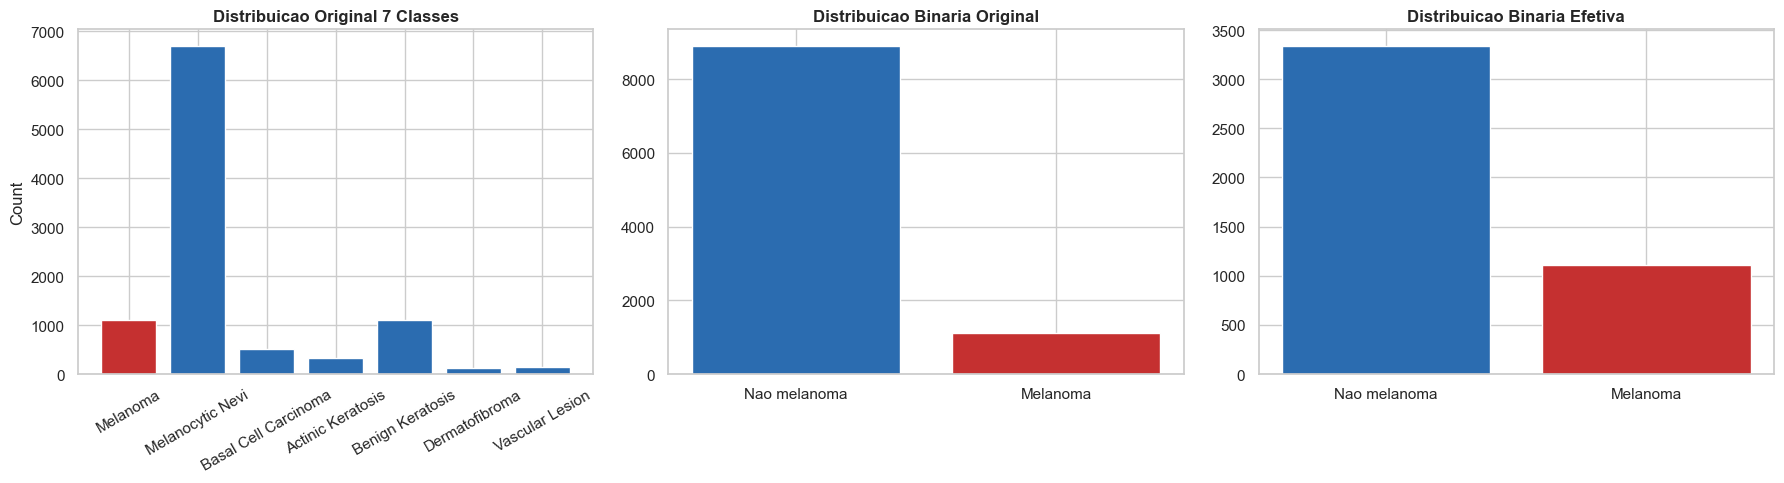

In [4]:
raw_class_counts = raw_df["label"].value_counts().reindex(CLASSES)
effective_class_counts = effective_df["label"].value_counts().reindex(CLASSES)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(
    [CLASS_NAMES[label] for label in raw_class_counts.index],
    raw_class_counts.values,
    color=["#c53030" if label == "MEL" else "#2b6cb0" for label in raw_class_counts.index],
)
axes[0].set_title("Distribuicao Original 7 Classes", fontweight="bold")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_ylabel("Count")

raw_binary_counts = raw_df["binary_label"].value_counts().sort_index()
axes[1].bar(["Nao melanoma", "Melanoma"], raw_binary_counts.values, color=["#2b6cb0", "#c53030"])
axes[1].set_title("Distribuicao Binaria Original", fontweight="bold")

effective_binary_counts = effective_df["binary_label"].value_counts().sort_index()
axes[2].bar(["Nao melanoma", "Melanoma"], effective_binary_counts.values, color=["#2b6cb0", "#c53030"])
axes[2].set_title("Distribuicao Binaria Efetiva", fontweight="bold")

plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
        

## 4. Amostras visuais por classe
        

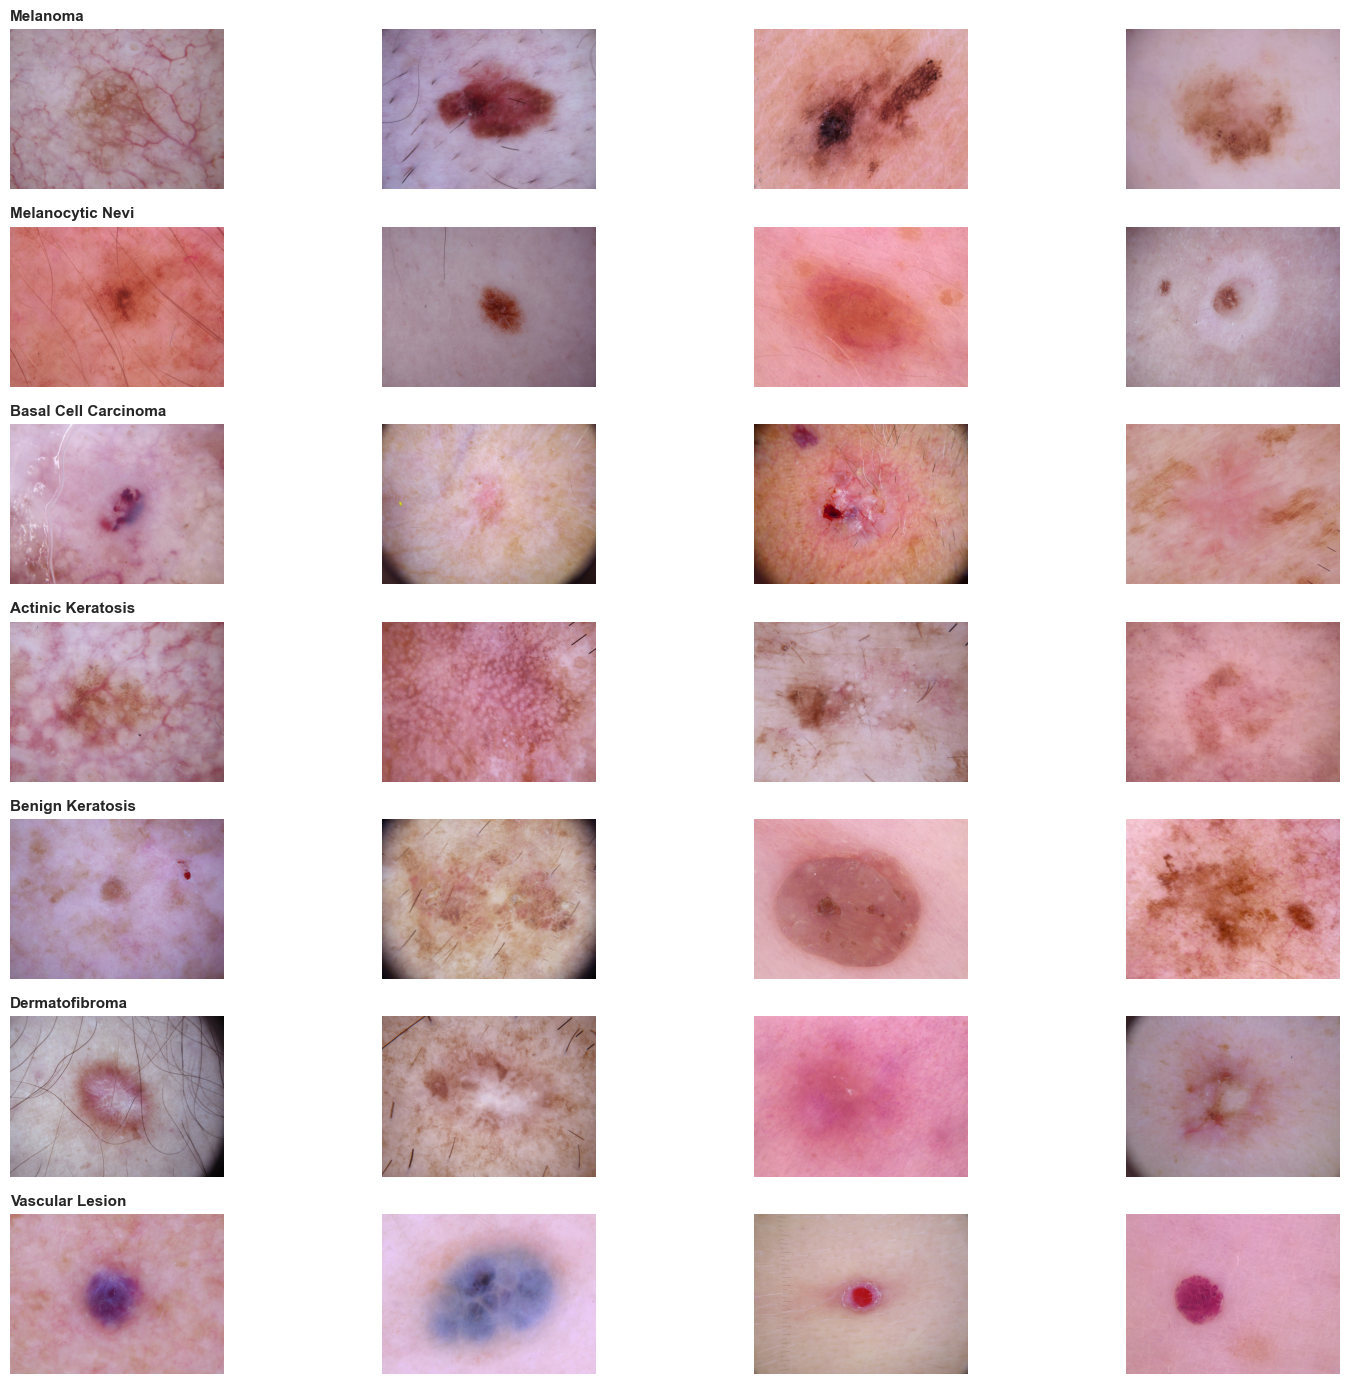

Amostras por classe geradas a partir do dataset efetivo.


In [5]:
N_SAMPLES = 4

fig = plt.figure(figsize=(16, 14))
grid = gridspec.GridSpec(len(CLASSES), N_SAMPLES)

for row, cls in enumerate(CLASSES):
    samples = effective_df[effective_df["label"] == cls].sample(
        n=min(N_SAMPLES, (effective_df["label"] == cls).sum()),
        random_state=SEED,
    )
    for col, (_, sample_row) in enumerate(samples.iterrows()):
        ax = fig.add_subplot(grid[row, col])
        ax.imshow(Image.open(sample_row["img_path"]).convert("RGB"))
        ax.axis("off")
        if col == 0:
            ax.set_title(CLASS_NAMES[cls], loc="left", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(FIG_DIR / "sample_images.png", dpi=150, bbox_inches="tight")
plt.show()
print("Amostras por classe geradas a partir do dataset efetivo.")
        

## 5. Melanoma vs nevi

`NV` continua sendo o hard negative dominante no problema binário.
        

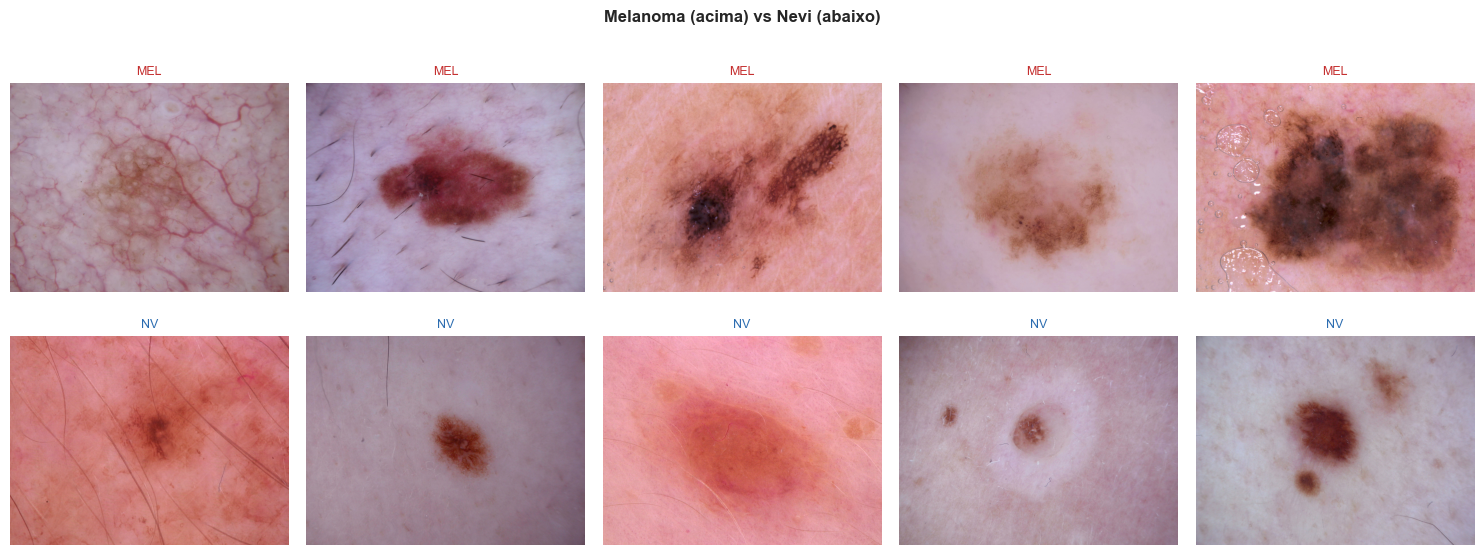

In [6]:
N = 5
mel_samples = effective_df[effective_df["label"] == "MEL"].sample(n=N, random_state=SEED)
nv_samples = effective_df[effective_df["label"] == "NV"].sample(n=N, random_state=SEED)

fig, axes = plt.subplots(2, N, figsize=(N * 3, 6))
fig.suptitle("Melanoma (acima) vs Nevi (abaixo)", fontsize=12, fontweight="bold")

for i, (_, row) in enumerate(mel_samples.iterrows()):
    axes[0, i].imshow(Image.open(row["img_path"]).convert("RGB"))
    axes[0, i].set_title("MEL", color="#c53030", fontsize=9)
    axes[0, i].axis("off")

for i, (_, row) in enumerate(nv_samples.iterrows()):
    axes[1, i].imshow(Image.open(row["img_path"]).convert("RGB"))
    axes[1, i].set_title("NV", color="#2b6cb0", fontsize=9)
    axes[1, i].axis("off")

plt.tight_layout()
plt.savefig(FIG_DIR / "mel_vs_nv.png", dpi=150, bbox_inches="tight")
plt.show()
        

## 6. Dimensões das imagens
        

In [7]:
dimension_sample = effective_df.sample(n=min(300, len(effective_df)), random_state=SEED)
sizes = dimension_sample["img_path"].map(lambda path: Image.open(path).size)
size_counts = pd.Series(list(sizes)).value_counts()

display(size_counts.to_frame(name="count"))
print(f"Quantidade de tamanhos distintos na amostra: {len(size_counts)}")
        

,count
"(600, 450)",300


Quantidade de tamanhos distintos na amostra: 1


## 7. Estatísticas de pixel
        

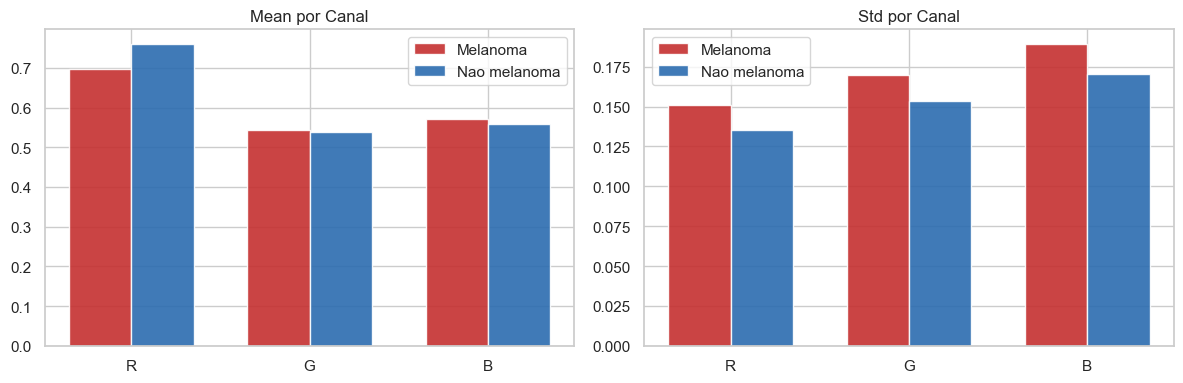

Melanoma mean RGB: [0.6964637 0.5424894 0.570766 ] | std: [0.15092096 0.1699319  0.18892872]
Nao melanoma mean RGB: [0.75874203 0.5386489  0.5579666 ] | std: [0.13548468 0.15376447 0.17072062]


In [8]:
def channel_stats(paths: list[Path], n: int = 80, seed: int = SEED) -> tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    sample_count = min(n, len(paths))
    indices = rng.choice(len(paths), size=sample_count, replace=False)
    pixels = []

    for idx in indices:
        arr = np.array(Image.open(paths[idx]).convert("RGB").resize((224, 224))).astype(np.float32) / 255.0
        pixels.append(arr.reshape(-1, 3))

    pixels = np.vstack(pixels)
    return pixels.mean(axis=0), pixels.std(axis=0)


mel_paths = effective_df[effective_df["binary_label"] == 1]["img_path"].tolist()
nonmel_paths = effective_df[effective_df["binary_label"] == 0]["img_path"].tolist()

mel_mean, mel_std = channel_stats(mel_paths)
nonmel_mean, nonmel_std = channel_stats(nonmel_paths)

channels = ["R", "G", "B"]
x = np.arange(3)
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(x - w / 2, mel_mean, w, label="Melanoma", color="#c53030", alpha=0.9)
axes[0].bar(x + w / 2, nonmel_mean, w, label="Nao melanoma", color="#2b6cb0", alpha=0.9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(channels)
axes[0].set_title("Mean por Canal")
axes[0].legend()

axes[1].bar(x - w / 2, mel_std, w, label="Melanoma", color="#c53030", alpha=0.9)
axes[1].bar(x + w / 2, nonmel_std, w, label="Nao melanoma", color="#2b6cb0", alpha=0.9)
axes[1].set_xticks(x)
axes[1].set_xticklabels(channels)
axes[1].set_title("Std por Canal")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "pixel_stats.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Melanoma mean RGB: {mel_mean} | std: {mel_std}")
print(f"Nao melanoma mean RGB: {nonmel_mean} | std: {nonmel_std}")
        

## 8. Inspeção de máscaras
        

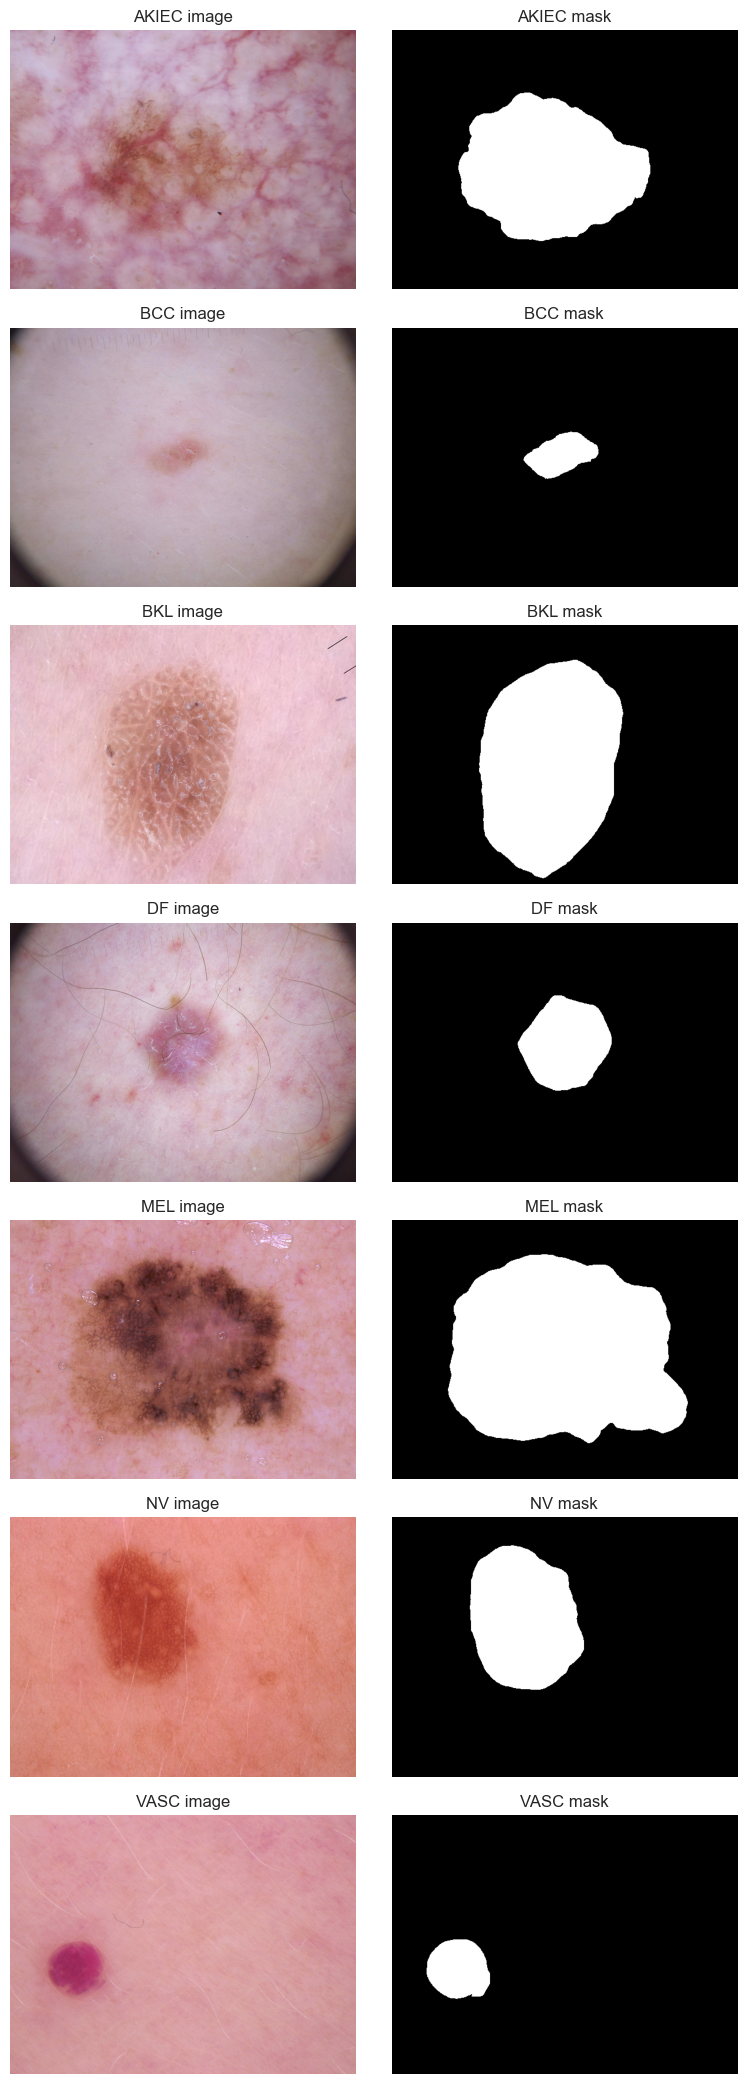

In [9]:
mask_samples = (
    effective_df.groupby("label", group_keys=False)
    .sample(n=1, random_state=SEED)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(len(mask_samples), 2, figsize=(8, 3 * len(mask_samples)))

for row_idx, (_, row) in enumerate(mask_samples.iterrows()):
    image = Image.open(row["img_path"]).convert("RGB")
    mask = np.array(Image.open(row["mask_path"]).convert("L"))

    axes[row_idx, 0].imshow(image)
    axes[row_idx, 0].set_title(f"{row['label']} image")
    axes[row_idx, 0].axis("off")

    axes[row_idx, 1].imshow(mask, cmap="gray")
    axes[row_idx, 1].set_title(f"{row['label']} mask")
    axes[row_idx, 1].axis("off")

plt.tight_layout()
plt.savefig(FIG_DIR / "masks_inspection.png", dpi=150, bbox_inches="tight")
plt.show()
        

## 9. Cobertura das lesões
        

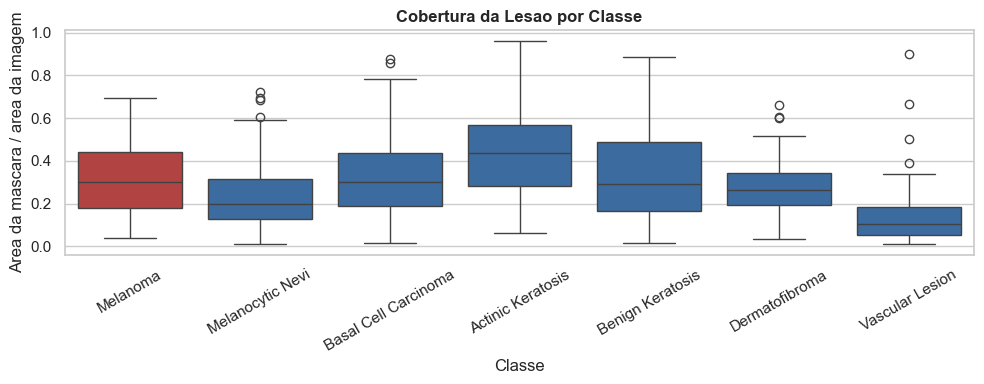

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
AKIEC,60.0,0.445,0.213,0.061,0.284,0.435,0.570,0.963
BCC,60.0,0.324,0.204,0.018,0.190,0.300,0.438,0.878
BKL,60.0,0.340,0.221,0.017,0.166,0.293,0.488,0.885
DF,43.0,0.288,0.145,0.032,0.193,0.264,0.346,0.661
MEL,60.0,0.308,0.162,0.038,0.180,0.299,0.442,0.692
NV,60.0,0.248,0.177,0.013,0.129,0.198,0.317,0.724
VASC,53.0,0.151,0.168,0.010,0.052,0.106,0.184,0.902


In [10]:
def lesion_coverage(mask_path: Path) -> float:
    mask = np.array(Image.open(mask_path).convert("L")) > 0
    return float(mask.mean())


coverage_df = pd.concat(
    [group.sample(n=min(60, len(group)), random_state=SEED) for _, group in effective_df.groupby("label")]
).reset_index(drop=True)
coverage_df["coverage"] = coverage_df["mask_path"].map(lesion_coverage)

plt.figure(figsize=(10, 4))
sns.boxplot(
    data=coverage_df,
    x="label",
    y="coverage",
    order=CLASSES,
    palette=["#c53030" if cls == "MEL" else "#2b6cb0" for cls in CLASSES],
)
plt.title("Cobertura da Lesao por Classe", fontweight="bold")
plt.xlabel("Classe")
plt.ylabel("Area da mascara / area da imagem")
plt.xticks(ticks=range(len(CLASSES)), labels=[CLASS_NAMES[cls] for cls in CLASSES], rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / "lesion_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

display(coverage_df.groupby("label")["coverage"].describe().round(3))
        

## 10. Resumo e insights
        

In [11]:
raw_ratio = (raw_df["binary_label"] == 0).sum() / (raw_df["binary_label"] == 1).sum()
effective_ratio = (effective_df["binary_label"] == 0).sum() / (effective_df["binary_label"] == 1).sum()
effective_negative_counts = effective_df[effective_df["binary_label"] == 0]["label"].value_counts()
dominant_negative_label = effective_negative_counts.idxmax()
dominant_negative_share = effective_negative_counts.iloc[0] / effective_negative_counts.sum() * 100
size_mode = size_counts.index[0]
size_mode_pct = size_counts.iloc[0] / size_counts.sum() * 100
coverage_medians = coverage_df.groupby("label")["coverage"].median().sort_values(ascending=False)

summary_table = pd.DataFrame(
    [
        {"metrica": "total_bruto", "valor": len(raw_df)},
        {"metrica": "melanoma_bruto", "valor": int((raw_df["binary_label"] == 1).sum())},
        {"metrica": "nao_melanoma_bruto", "valor": int((raw_df["binary_label"] == 0).sum())},
        {"metrica": "ratio_bruto", "valor": f"{raw_ratio:.2f}:1"},
        {"metrica": "total_efetivo", "valor": len(effective_df)},
        {"metrica": "ratio_efetivo", "valor": f"{effective_ratio:.2f}:1"},
        {"metrica": "hard_negative_dominante", "valor": dominant_negative_label},
    ]
)
display(summary_table)

print("Insights:")
print(
    f"- O dataset bruto apresenta desbalanceamento relevante de {raw_ratio:.2f}:1 "
    f"(nao melanoma:melanoma), o que justifica algum grau de balanceamento antes do treino."
)
print(
    f"- O dataset efetivo reduz esse desbalanceamento para {effective_ratio:.2f}:1 "
    f"mantendo todos os melanomas e reduzindo apenas a classe negativa."
)
print(
    f"- NV continua sendo o principal hard negative, representando "
    f"{dominant_negative_share:.1f}% dos nao melanomas no dataset efetivo."
)
print(
    f"- As imagens e mascaras sao espacialmente consistentes: o tamanho dominante e "
    f"{size_mode[0]}x{size_mode[1]} em {size_mode_pct:.1f}% da amostra inspecionada."
)
print(
    f"- A cobertura mediana da lesao varia entre classes, reforcando a utilidade das mascaras "
    f"para recorte lesion-centric no preprocessing."
)
        

,metrica,valor
0,total_bruto,10015
1,melanoma_bruto,1113
2,nao_melanoma_bruto,8902
3,ratio_bruto,8.00:1
4,total_efetivo,4452
5,ratio_efetivo,3.00:1
6,hard_negative_dominante,NV


Insights:
- O dataset bruto apresenta desbalanceamento relevante de 8.00:1 (nao melanoma:melanoma), o que justifica algum grau de balanceamento antes do treino.
- O dataset efetivo reduz esse desbalanceamento para 3.00:1 mantendo todos os melanomas e reduzindo apenas a classe negativa.
- NV continua sendo o principal hard negative, representando 75.3% dos nao melanomas no dataset efetivo.
- As imagens e mascaras sao espacialmente consistentes: o tamanho dominante e 600x450 em 100.0% da amostra inspecionada.
- A cobertura mediana da lesao varia entre classes, reforcando a utilidade das mascaras para recorte lesion-centric no preprocessing.
